In [30]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

In [8]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

data = x_train
labels = np.asarray(y_train, dtype=np.int32)

test_data = x_test
test_labels = np.asarray(y_test, dtype=np.int32)

In [9]:
max_examples = 10000
data = data[:max_examples]
labels = labels[:max_examples]

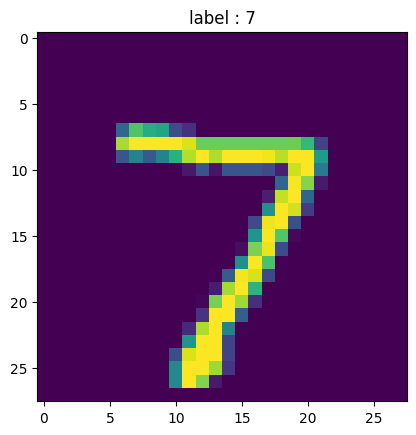

In [10]:
def display(i):
  img = test_data[i]
  plt.title('label : {}'.format(test_labels[i]))
  plt.imshow(img.reshape(28,28))

display(0)

In [12]:
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28)),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
  optimizer='sgd',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

model.fit(data, labels, batch_size=10, epochs=10)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 483us/step - accuracy: 0.8023 - loss: 859.2987 
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.8622 - loss: 603.4822
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - accuracy: 0.8742 - loss: 548.0131
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.8823 - loss: 518.0329
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - accuracy: 0.8800 - loss: 525.6589
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.8890 - loss: 497.7661
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 495us/step - accuracy: 0.8891 - loss: 462.0488
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.8955 - loss: 457.4988
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.9004 - loss: 430.7196
Epoch 10/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - accuracy: 0.9000 - loss: 398.6897


In [15]:
model.evaluate(test_data, test_labels)
print(model.evaluate(test_data, test_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - accuracy: 0.8758 - loss: 734.7543
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - accuracy: 0.8758 - loss: 734.7543
[734.7542724609375, 0.8758000135421753]


In [17]:
prediction = model.predict(np.array([test_data[0]]))
predicted_class = np.argmax(prediction[0])
print("prediction: ",predicted_class)
print("label: ",test_labels[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
prediction:  7
label:  7


In [18]:
x_train_dl = tf.keras.utils.normalize(x_train,axis=1)
x_test_dl = tf.keras.utils.normalize(x_test,axis=1)

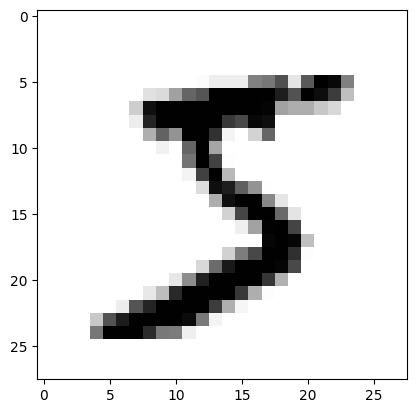

In [19]:
def draw(n):
  plt.imshow(n, cmap=plt.cm.binary)
  plt.show()

draw(x_train[0])

In [24]:
model_dl = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28)),
  tf.keras.layers.Dense(128,activation='relu'),
  tf.keras.layers.Dense(128,activation='relu'),
  tf.keras.layers.Dense(10,activation='softmax')
])

model_dl.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_dl.fit(x_train_dl, y_train, epochs=3)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9210 - loss: 0.2702
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9655 - loss: 0.1112
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9763 - loss: 0.0760


In [25]:
val_loss, val_acc = model_dl.evaluate(x_test_dl, y_test)
print("loss-> ", val_loss,"\nacc-> ",val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - accuracy: 0.9728 - loss: 0.0924
loss->  0.09236366301774979 
acc->  0.9728000164031982


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step
label ->  1
prediction ->  1


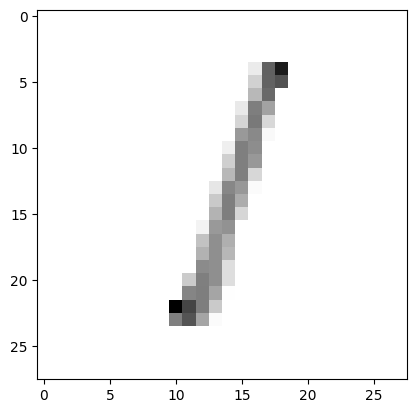

In [31]:
predictions=model.predict([x_test_dl])
print('label -> ', y_test[2])
print('prediction -> ', np.argmax(predictions[2]))

draw(x_test_dl[2])

In [33]:
model_dl.save('epic_num_reader.h5')
new_model = tf.keras.models.load_model('epic_num_reader.h5')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step
label ->  0
prediction ->  0


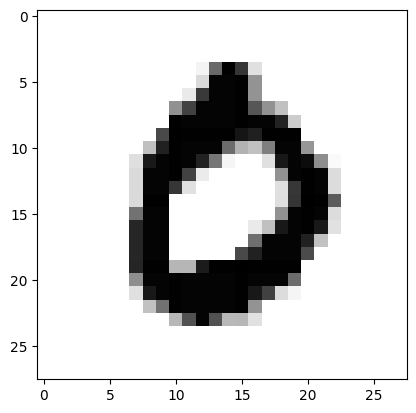

In [34]:
predictions = new_model.predict([x_test_dl])

print('label -> ',y_test[3])
print('prediction -> ',np.argmax(predictions[3]))

draw(x_test[3])